<a href="https://colab.research.google.com/github/nurcankurt/speculative_decoding_analysis/blob/main/speculative_decoding_extended_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speculative Decoding Analysis
## Accelerating LLM Inference via Draft-Target Model Pairs

This notebook analyzes speculative decoding from an **AI perspective**, investigating:
- Token acceptance rate as a function of draft length K
- Inference speedup across draft model architectures
- **KL divergence** between draft and target model distributions (explains *why* acceptance rates differ)
- **Prompt domain sensitivity** (technical vs. narrative vs. factual text)
- **Temperature sensitivity** (greedy vs. stochastic decoding)
- **Token position analysis** (which positions in the draft are most likely to be rejected)

In [1]:
# ============================================================
# CELL 1: Environment Setup & Libraries
# ============================================================
!pip install -q transformers torch pandas datasets matplotlib seaborn

import time
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Execution Environment: {device.upper()}")
sns.set_theme(style="whitegrid", palette="muted")

Execution Environment: CUDA


In [2]:
# ============================================================
# CELL 2: Loading Target and Draft (Approximation) Models
# ============================================================
print("Loading models...")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Target Model: GPT-2 Large (774M parameters)
print("Loading Target Model (GPT-2 Large)...")
target_model = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)
target_model.eval()

# Draft (Approximation) Models: diverse architectures
print("Loading Draft Models...")
approximation_models = {
    "GPT-2 Medium (355M)": AutoModelForCausalLM.from_pretrained("gpt2-medium").to(device),
    "GPT-2 Base (117M)":   AutoModelForCausalLM.from_pretrained("gpt2").to(device),
    "DistilGPT-2 (82M)":   AutoModelForCausalLM.from_pretrained("distilgpt2").to(device),
    "GPT-Neo (125M)":      AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device),
    "Tiny-GPT2 (15M)":     AutoModelForCausalLM.from_pretrained("sshleifer/tiny-gpt2").to(device)
}
for m in approximation_models.values():
    m.eval()
print("All models loaded.")

Loading models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0, 1}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded.


In [3]:
# ============================================================
# CELL 3: Dataset & Prompt Selection
# ============================================================
print("Downloading WikiText-103 test split...")
wiki_dataset = load_dataset("wikitext", "wikitext-103-v1", split="test")
valid_texts = [t for t in wiki_dataset['text'] if len(t.split()) > 20]
sample_text = valid_texts[5]
default_prompt = " ".join(sample_text.split()[:12])
print(f"Default Prompt: '{default_prompt}...'")

# --- EXTENSION: Multi-domain prompt set for domain sensitivity analysis ---
DOMAIN_PROMPTS = {
    "Wikipedia (Factual)": default_prompt,
    "Technical / Code":    "The transformer architecture uses self-attention mechanisms to",
    "Narrative / Story":   "Once upon a time in a distant kingdom, a young knight set out",
    "Scientific":          "Recent studies in neuroscience have demonstrated that synaptic plasticity",
    "Conversational":      "Hey, what do you think about going to the movies tonight? I was"
}
print(f"\nDomain prompts loaded: {list(DOMAIN_PROMPTS.keys())}")

README.md: 0.00B [00:00, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Default Prompt: 'Boulter starred in two films in 2008 , Daylight Robbery by filmmaker...'

Domain prompts loaded: ['Wikipedia (Factual)', 'Technical / Code', 'Narrative / Story', 'Scientific', 'Conversational']


In [4]:
# ============================================================
# CELL 4: Core Algorithm — Speculative Decoding (Extended)
#   Now returns per-position acceptance flags and KL divergence
# ============================================================

def sample_from_distribution(logits, temperature=1.0):
    if temperature == 0.0:
        return torch.argmax(logits, dim=-1)
    probs = F.softmax(logits / temperature, dim=-1)
    return torch.multinomial(probs, 1)[0]

def get_probs_from_logits(logits, temperature=1.0):
    if temperature == 0.0:
        probs = torch.zeros_like(logits)
        probs[torch.argmax(logits)] = 1.0
        return probs
    return F.softmax(logits / temperature, dim=-1)

def calculate_perplexity(model, input_ids):
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
    return torch.exp(outputs.loss).item()

def kl_divergence(p, q, eps=1e-9):
    """KL(p || q): measures how much target distribution p differs from draft q.
    Lower KL => draft model is closer to target => higher acceptance rate expected."""
    p = p + eps
    q = q + eps
    return (p * (p / q).log()).sum().item()

def speculative_decoding_step(generated_ids, target_model, approximation_model,
                               gamma=4, temperature=0.0):
    """
    Extended step: also returns per-position acceptance flags and KL divergences.
    Returns: (new_generated_ids, accepted_count, position_flags, kl_values)
      - position_flags: list of length gamma, True = accepted at that position
      - kl_values:      KL(target || draft) at each draft position
    """
    step_ids = generated_ids.clone()
    draft_probs_list = []

    # PHASE 1: DRAFT — approximation model generates gamma tokens
    with torch.no_grad():
        for _ in range(gamma):
            logits = approximation_model(step_ids).logits[0, -1, :]
            probs  = get_probs_from_logits(logits, temperature)
            token  = sample_from_distribution(logits, temperature).unsqueeze(0).unsqueeze(0)
            step_ids = torch.cat([step_ids, token], dim=-1)
            draft_probs_list.append(probs)

    draft_tokens = step_ids[0, generated_ids.shape[1]:]

    # PHASE 2: VERIFY — target model scores all gamma tokens in one forward pass
    with torch.no_grad():
        target_logits_all = target_model(step_ids).logits[0]
        start = generated_ids.shape[1] - 1
        target_logits = target_logits_all[start: start + gamma + 1]

    # PHASE 3: ACCEPTANCE with per-position tracking
    position_flags = []   # True = accepted at this position
    kl_values      = []   # KL(target || draft) at each position
    n = gamma

    for i in range(gamma):
        token_id = draft_tokens[i].item()
        p_dist = get_probs_from_logits(target_logits[i], temperature)
        q_dist = draft_probs_list[i]

        # KL divergence: measures alignment between target and draft at this position
        kl_values.append(kl_divergence(p_dist, q_dist))

        p_val = p_dist[token_id].item()
        q_val = q_dist[token_id].item()

        r = torch.rand(1).item()
        if r > (p_val / (q_val + 1e-9)):
            position_flags.append(False)  # REJECTED at position i
            n = i
            break
        else:
            position_flags.append(True)   # ACCEPTED at position i

    # PHASE 4: CORRECTION — resample the rejected token from adjusted distribution
    if n < gamma:
        p_dist = get_probs_from_logits(target_logits[n], temperature)
        q_dist = draft_probs_list[n]
        if temperature == 0.0:
            t = torch.argmax(target_logits[n]).unsqueeze(0).unsqueeze(0)
        else:
            adj = torch.clamp(p_dist - q_dist, min=0.0)
            adj = adj / (adj.sum() + 1e-9)
            if adj.sum() == 0: adj = p_dist
            t = sample_from_distribution(torch.log(adj + 1e-9), 1.0).unsqueeze(0).unsqueeze(0)
    else:
        t = (torch.argmax(target_logits[n]) if temperature == 0.0
             else sample_from_distribution(target_logits[n], temperature)).unsqueeze(0).unsqueeze(0)

    prefix = (draft_tokens[:n].unsqueeze(0) if n > 0
              else torch.empty((1, 0), dtype=torch.long, device=device))
    new_ids = torch.cat([generated_ids, torch.cat([prefix, t], dim=-1)], dim=-1)
    return new_ids, n, position_flags, kl_values

In [5]:
# ============================================================
# CELL 5: Evaluation Engine (Baseline + Speculative, extended)
# ============================================================

def evaluate_baseline(input_text, target_model, tokenizer, max_length=60, temp=0.0):
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        out = target_model.generate(
            input_ids,
            max_new_tokens=max_length - input_ids.shape[1],
            do_sample=(temp > 0), temperature=temp if temp > 0 else None
        )
    if device == "cuda": torch.cuda.synchronize()
    latency = time.time() - t0
    gen_tokens = out.shape[1] - input_ids.shape[1]
    return {
        "Model": "Baseline", "K": 0,
        "Latency (s)": round(latency, 3),
        "Tokens/Sec": round(gen_tokens / latency, 2),
        "Acceptance Rate (%)": None,
        "Perplexity": round(calculate_perplexity(target_model, out), 2),
        "Avg KL Divergence": None
    }

def evaluate_speculative(input_text, target_model, approx_model, model_name,
                          tokenizer, k_gamma, max_length=60, temp=0.0,
                          collect_position_data=False):
    input_ids  = tokenizer.encode(input_text, return_tensors="pt").to(device)
    gen_ids    = input_ids.clone()
    total_acc  = 0
    total_draft = 0
    all_kl_values  = []
    position_counts = defaultdict(lambda: {"accepted": 0, "total": 0})  # pos -> stats

    if device == "cuda": torch.cuda.synchronize()
    t0 = time.time()

    while gen_ids.shape[1] < max_length:
        gen_ids, acc_count, pos_flags, kl_vals = speculative_decoding_step(
            gen_ids, target_model, approx_model, gamma=k_gamma, temperature=temp
        )
        total_acc   += acc_count
        total_draft += k_gamma
        all_kl_values.extend(kl_vals)

        if collect_position_data:
            for pos, accepted in enumerate(pos_flags):
                position_counts[pos]["total"]    += 1
                position_counts[pos]["accepted"] += int(accepted)

        if gen_ids[0, -1].item() == tokenizer.eos_token_id:
            break

    if device == "cuda": torch.cuda.synchronize()
    latency = time.time() - t0
    gen_tokens = gen_ids.shape[1] - input_ids.shape[1]
    acc_rate   = (total_acc / total_draft * 100) if total_draft > 0 else 0
    avg_kl     = float(np.mean(all_kl_values)) if all_kl_values else 0

    result = {
        "Model": model_name, "K": k_gamma,
        "Latency (s)": round(latency, 3),
        "Tokens/Sec":  round(gen_tokens / latency, 2),
        "Acceptance Rate (%)": round(acc_rate, 1),
        "Perplexity":  round(calculate_perplexity(target_model, gen_ids), 2),
        "Avg KL Divergence": round(avg_kl, 4)
    }
    if collect_position_data:
        result["_position_counts"] = dict(position_counts)
    return result

In [6]:
# ============================================================
# CELL 6: EXPERIMENT 1 — Main Benchmark (all models, K=1..8)
#   Same as original; now also captures KL divergence.
# ============================================================
print("=" * 70)
print("EXPERIMENT 1: Main Benchmark — Multiple Models, K=1 to 8")
print("=" * 70)

TEST_TEMP   = 0.0
MAX_SEQ_LEN = 80

results = [evaluate_baseline(default_prompt, target_model, tokenizer,
                              max_length=MAX_SEQ_LEN, temp=TEST_TEMP)]

for name, model in approximation_models.items():
    print(f"  Testing {name} ...")
    for k in range(1, 9):
        results.append(evaluate_speculative(
            default_prompt, target_model, model, name,
            tokenizer, k_gamma=k, max_length=MAX_SEQ_LEN, temp=TEST_TEMP
        ))

df = pd.DataFrame(results)
print("\n--- EXPERIMENT 1 DATA ---")
print(df.to_string(index=False))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


EXPERIMENT 1: Main Benchmark — Multiple Models, K=1 to 8


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Testing GPT-2 Medium (355M) ...
  Testing GPT-2 Base (117M) ...
  Testing DistilGPT-2 (82M) ...
  Testing GPT-Neo (125M) ...
  Testing Tiny-GPT2 (15M) ...

--- EXPERIMENT 1 DATA ---
              Model  K  Latency (s)  Tokens/Sec  Acceptance Rate (%)  Perplexity  Avg KL Divergence
           Baseline  0        5.887       11.04                  NaN        6.58                NaN
GPT-2 Medium (355M)  1        2.233       29.11                 71.1        6.58             5.9988
GPT-2 Medium (355M)  2        2.674       24.31                 62.1        6.58             5.4980
GPT-2 Medium (355M)  3        2.473       26.28                 53.3        6.58             5.6518
GPT-2 Medium (355M)  4        2.648       24.55                 45.7        6.58             5.7168
GPT-2 Medium (355M)  5        2.865       22.69                 41.9        6.58             5.2686
GPT-2 Medium (355M)  6        3.119       20.84                 40.4        6.58             5.3479
GPT-2 Medium (35

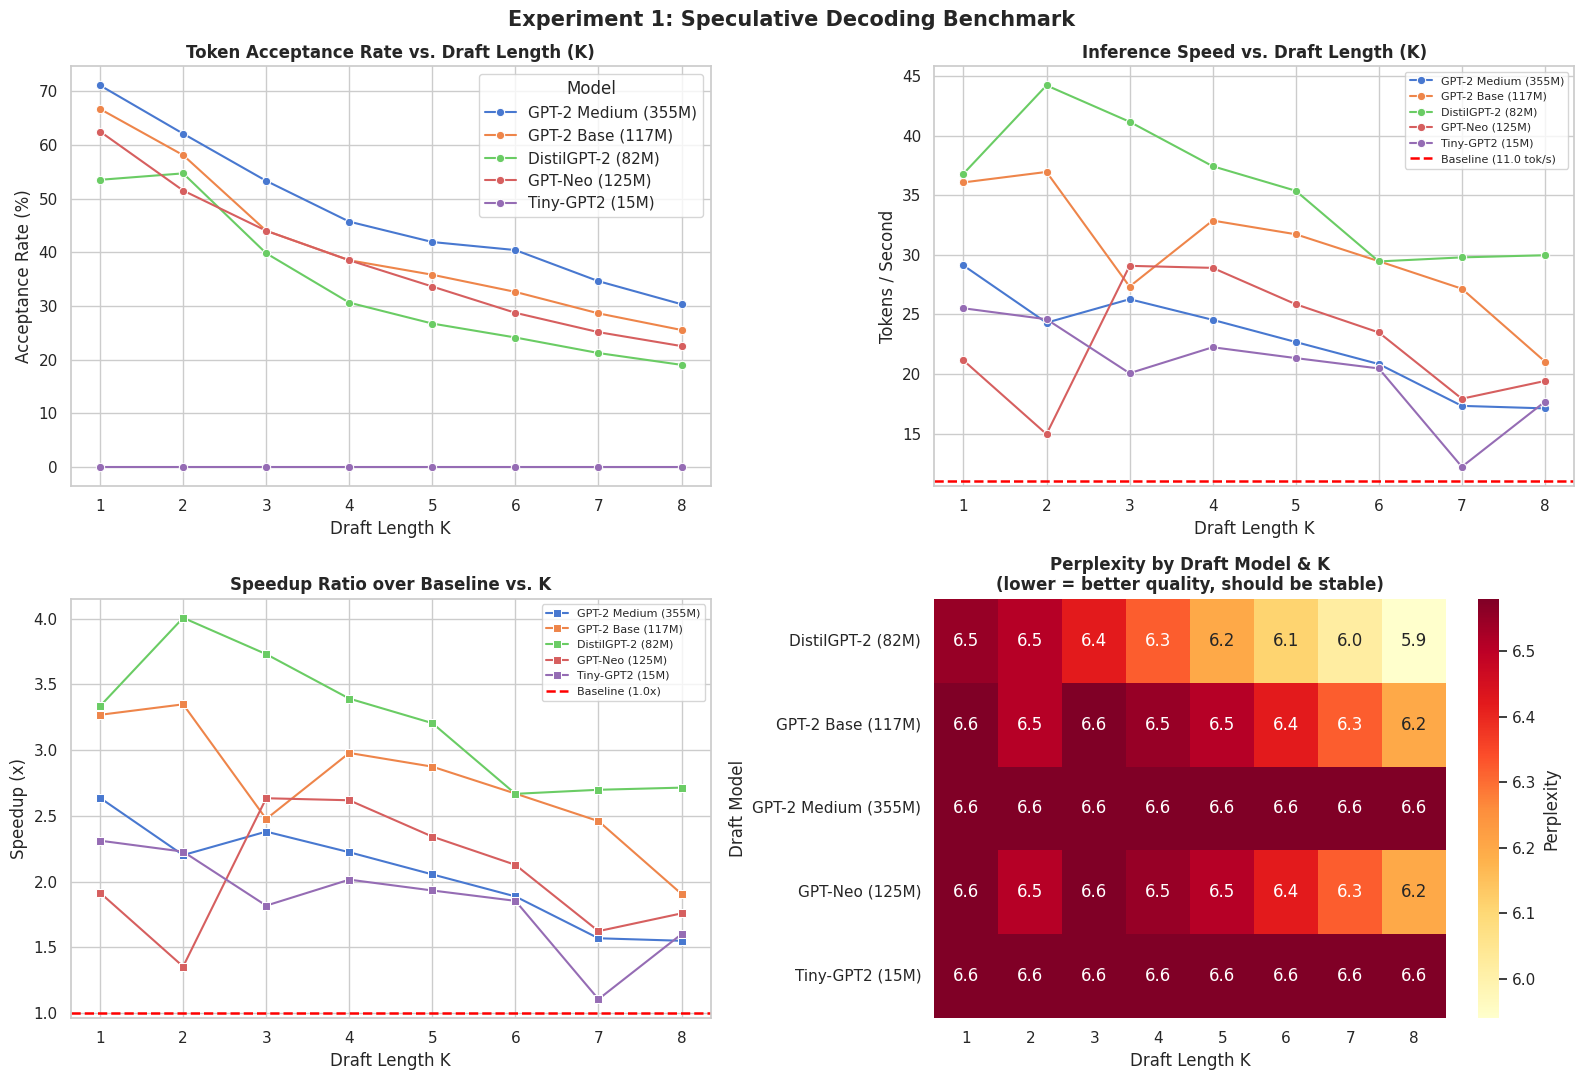

Saved: exp1_main_benchmark.png


In [7]:
# ============================================================
# CELL 7: VISUALIZATIONS — Set 1 (Original + Extended)
#   Plot 1 : Acceptance Rate vs K         (original)
#   Plot 2 : Tokens/Sec vs K              (original)
#   Plot 3 : Speedup Ratio vs K           (NEW)
#   Plot 4 : Perplexity heatmap           (NEW)
# ============================================================
df_spec     = df[df["Model"] != "Baseline"].copy()
baseline_tps = df[df["Model"] == "Baseline"]["Tokens/Sec"].iloc[0]
df_spec["Speedup"] = df_spec["Tokens/Sec"] / baseline_tps

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Experiment 1: Speculative Decoding Benchmark", fontsize=15, fontweight="bold")

# --- Plot 1: Acceptance Rate vs K ---
sns.lineplot(data=df_spec, x="K", y="Acceptance Rate (%)", hue="Model",
             marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Token Acceptance Rate vs. Draft Length (K)", fontweight="bold")
axes[0, 0].set_xlabel("Draft Length K")
axes[0, 0].set_ylabel("Acceptance Rate (%)")
axes[0, 0].set_xticks(range(1, 9))

# --- Plot 2: Tokens/Sec vs K ---
sns.lineplot(data=df_spec, x="K", y="Tokens/Sec", hue="Model",
             marker="o", ax=axes[0, 1])
axes[0, 1].axhline(baseline_tps, ls="--", color="red", linewidth=1.8,
                    label=f"Baseline ({baseline_tps:.1f} tok/s)")
axes[0, 1].set_title("Inference Speed vs. Draft Length (K)", fontweight="bold")
axes[0, 1].set_xlabel("Draft Length K")
axes[0, 1].set_ylabel("Tokens / Second")
axes[0, 1].set_xticks(range(1, 9))
axes[0, 1].legend(fontsize=8)

# --- Plot 3 (NEW): Speedup Ratio vs K ---
# Speedup ratio directly shows whether speculative decoding is worth it
sns.lineplot(data=df_spec, x="K", y="Speedup", hue="Model",
             marker="s", ax=axes[1, 0])
axes[1, 0].axhline(1.0, ls="--", color="red", linewidth=1.8, label="Baseline (1.0x)")
axes[1, 0].set_title("Speedup Ratio over Baseline vs. K", fontweight="bold")
axes[1, 0].set_xlabel("Draft Length K")
axes[1, 0].set_ylabel("Speedup (x)")
axes[1, 0].set_xticks(range(1, 9))
axes[1, 0].legend(fontsize=8)

# --- Plot 4 (NEW): Perplexity Heatmap — model vs K ---
# Verifies that speculative decoding preserves output quality
pivot_ppl = df_spec.pivot(index="Model", columns="K", values="Perplexity")
sns.heatmap(pivot_ppl, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[1, 1], cbar_kws={"label": "Perplexity"})
axes[1, 1].set_title("Perplexity by Draft Model & K\n(lower = better quality, should be stable)",
                      fontweight="bold")
axes[1, 1].set_xlabel("Draft Length K")
axes[1, 1].set_ylabel("Draft Model")

plt.tight_layout()
plt.savefig("exp1_main_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: exp1_main_benchmark.png")

In [9]:
# ============================================================
# CELL 8: EXPERIMENT 2 — KL Divergence Analysis  [NEW — AI FOCUS]
#
# Hypothesis: Draft models with lower KL divergence from the target
# should achieve higher token acceptance rates.
# This directly connects speculative decoding to the theory of
# rejection sampling and surrogate model approximation.
# ============================================================
print("=" * 70)
print("EXPERIMENT 2: KL Divergence vs. Acceptance Rate")
print("=" * 70)

# Use K=4 (mid-range) for a representative comparison
kl_results = []
for name, model in approximation_models.items():
    print(f"  Collecting KL stats for {name} ...")
    res = evaluate_speculative(
        default_prompt, target_model, model, name,
        tokenizer, k_gamma=4, max_length=MAX_SEQ_LEN, temp=TEST_TEMP
    )
    kl_results.append(res)

df_kl = pd.DataFrame(kl_results)
print("\n--- KL Divergence Results (K=4) ---")
print(df_kl[["Model", "Avg KL Divergence", "Acceptance Rate (%)", "Speedup" if "Speedup" in df_kl.columns else "Tokens/Sec"]].to_string(index=False))

EXPERIMENT 2: KL Divergence vs. Acceptance Rate

--- KL Divergence Results (K=4) ---
              Model  Avg KL Divergence  Acceptance Rate (%)  Tokens/Sec
GPT-2 Medium (355M)             5.7168                 45.7       15.28
  GPT-2 Base (117M)             6.9078                 38.5       14.89
  DistilGPT-2 (82M)             8.7917                 30.6       18.71
     GPT-Neo (125M)             7.3534                 38.5       14.07
    Tiny-GPT2 (15M)            20.7233                  0.0       11.35


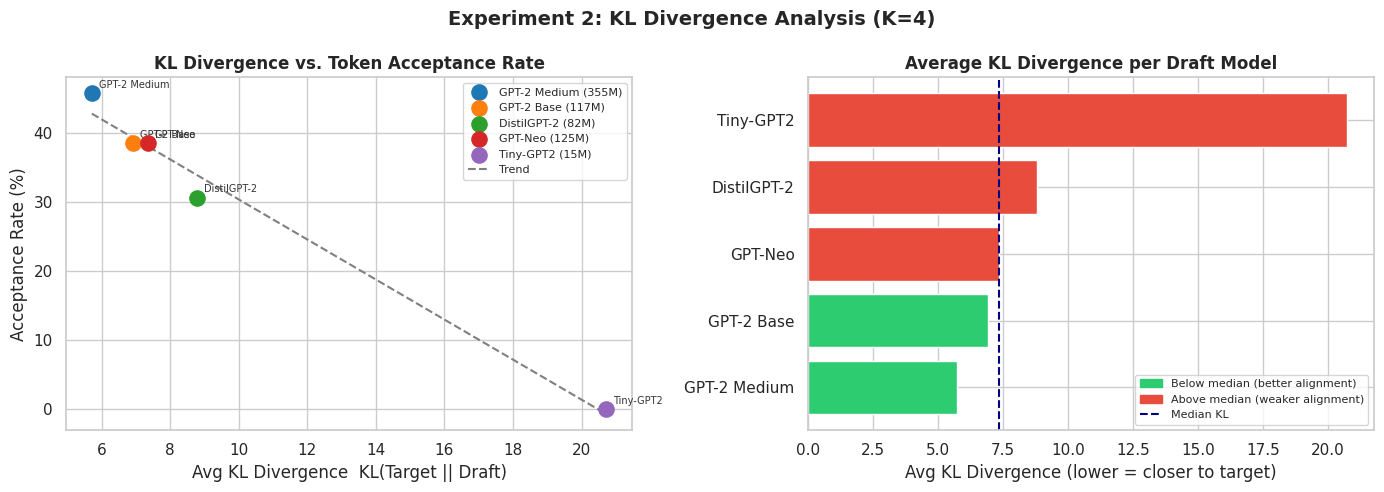

Saved: exp2_kl_divergence.png


In [10]:
# ============================================================
# CELL 9: VISUALIZATION — KL Divergence Scatter  [NEW]
#   Plot 5: KL Divergence vs Acceptance Rate (scatter + regression)
#   Plot 6: KL Divergence bar chart (model comparison)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Experiment 2: KL Divergence Analysis (K=4)", fontsize=14, fontweight="bold")

# --- Plot 5 (NEW): Scatter — KL Divergence vs Acceptance Rate ---
# Core AI insight: lower KL ↔ higher acceptance (rejection sampling theory)
scatter_colors = sns.color_palette("tab10", len(df_kl))
for i, (_, row) in enumerate(df_kl.iterrows()):
    axes[0].scatter(row["Avg KL Divergence"], row["Acceptance Rate (%)"],
                    s=120, color=scatter_colors[i], label=row["Model"], zorder=5)

# Regression line
kl_vals  = df_kl["Avg KL Divergence"].values
acc_vals = df_kl["Acceptance Rate (%)"].values
z = np.polyfit(kl_vals, acc_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(kl_vals.min(), kl_vals.max(), 100)
axes[0].plot(x_line, p(x_line), "--", color="gray", linewidth=1.5, label="Trend")

axes[0].set_title("KL Divergence vs. Token Acceptance Rate", fontweight="bold")
axes[0].set_xlabel("Avg KL Divergence  KL(Target || Draft)")
axes[0].set_ylabel("Acceptance Rate (%)")
axes[0].legend(fontsize=8)

# Annotate each point with model name
short_names = {m: m.split("(")[0].strip() for m in df_kl["Model"]}
for _, row in df_kl.iterrows():
    axes[0].annotate(short_names[row["Model"]],
                     (row["Avg KL Divergence"], row["Acceptance Rate (%)"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7, color="#333")

# --- Plot 6 (NEW): KL Divergence bar chart ---
df_kl_sorted = df_kl.sort_values("Avg KL Divergence")
bar_colors   = ["#2ecc71" if v < df_kl["Avg KL Divergence"].median() else "#e74c3c"
                for v in df_kl_sorted["Avg KL Divergence"]]
axes[1].barh(df_kl_sorted["Model"].apply(lambda x: x.split("(")[0].strip()),
              df_kl_sorted["Avg KL Divergence"], color=bar_colors, edgecolor="white")
axes[1].axvline(df_kl["Avg KL Divergence"].median(), ls="--", color="navy",
                 linewidth=1.5, label="Median KL")
axes[1].set_title("Average KL Divergence per Draft Model", fontweight="bold")
axes[1].set_xlabel("Avg KL Divergence (lower = closer to target)")
green_patch = mpatches.Patch(color='#2ecc71', label='Below median (better alignment)')
red_patch   = mpatches.Patch(color='#e74c3c', label='Above median (weaker alignment)')
axes[1].legend(handles=[green_patch, red_patch, plt.Line2D([0],[0],ls='--',color='navy',label='Median KL')], fontsize=8)

plt.tight_layout()
plt.savefig("exp2_kl_divergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: exp2_kl_divergence.png")

In [11]:
# ============================================================
# CELL 10: EXPERIMENT 3 — Token Position Analysis  [NEW — AI FOCUS]
#
# Within a draft of K tokens, does rejection probability increase
# at later positions? This reflects how draft model errors
# compound over the auto-regressive chain.
# ============================================================
print("=" * 70)
print("EXPERIMENT 3: Token Position Rejection Analysis (K=8)")
print("=" * 70)

POSITION_K   = 8
position_data_by_model = {}

for name, model in approximation_models.items():
    print(f"  Collecting position stats for {name} ...")
    res = evaluate_speculative(
        default_prompt, target_model, model, name,
        tokenizer, k_gamma=POSITION_K, max_length=MAX_SEQ_LEN,
        temp=TEST_TEMP, collect_position_data=True
    )
    if "_position_counts" in res:
        pcounts = res["_position_counts"]
        for pos in range(POSITION_K):
            stats = pcounts.get(pos, {"accepted": 0, "total": 1})
            acc_r = stats["accepted"] / max(stats["total"], 1) * 100
            position_data_by_model.setdefault(name, {})[pos] = acc_r

# Build DataFrame
pos_rows = []
for model_name, pos_dict in position_data_by_model.items():
    for pos, rate in pos_dict.items():
        pos_rows.append({"Model": model_name, "Position": pos + 1,
                         "Acceptance Rate (%)": rate})
df_pos = pd.DataFrame(pos_rows)
print(df_pos.pivot(index="Position", columns="Model",
                    values="Acceptance Rate (%)").round(1).to_string())

EXPERIMENT 3: Token Position Rejection Analysis (K=8)
Model     DistilGPT-2 (82M)  GPT-2 Base (117M)  GPT-2 Medium (355M)  GPT-Neo (125M)  Tiny-GPT2 (15M)
Position                                                                                            
1                      65.5               69.6                 68.4            64.0              0.0
2                      63.2               62.5                 76.9            75.0              0.0
3                      25.0               70.0                 70.0            66.7              0.0
4                     100.0               85.7                 71.4            50.0              0.0
5                     100.0               66.7                 80.0            50.0              0.0
6                      66.7               50.0                 75.0            50.0              0.0
7                      50.0               50.0                 66.7           100.0              0.0
8                     100.0          

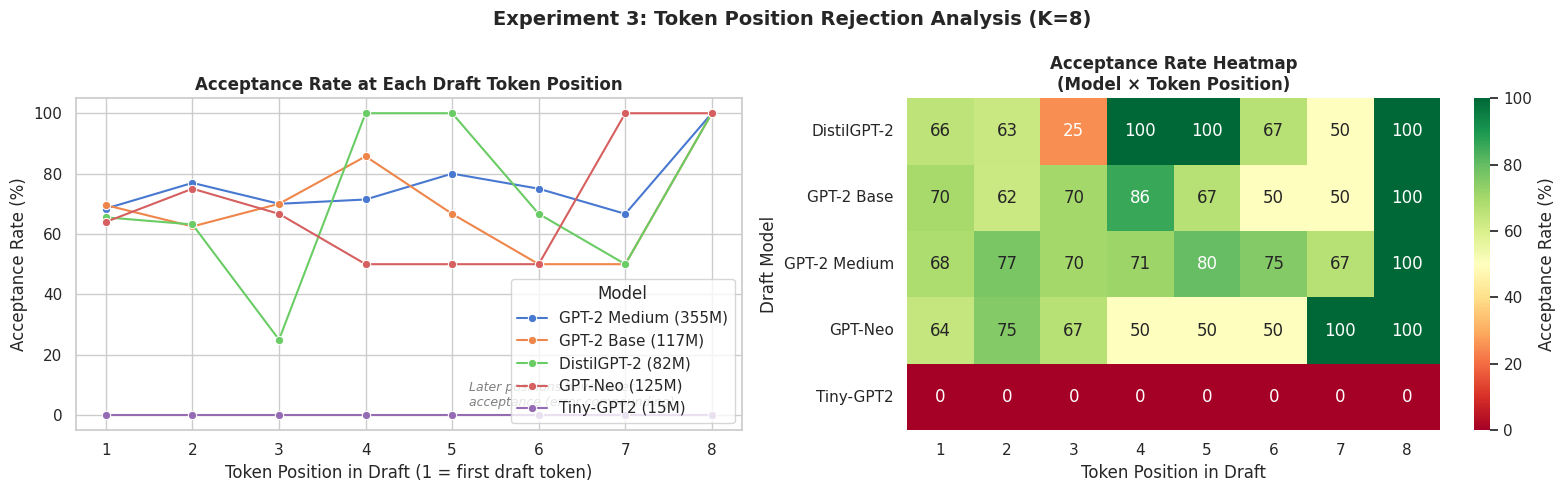

Saved: exp3_position_analysis.png


In [12]:
# ============================================================
# CELL 11: VISUALIZATION — Token Position Analysis  [NEW]
#   Plot 7: Per-position acceptance rate line chart
#   Plot 8: Heatmap (model vs position)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Experiment 3: Token Position Rejection Analysis (K=8)",
             fontsize=14, fontweight="bold")

# --- Plot 7 (NEW): Acceptance Rate by Position ---
sns.lineplot(data=df_pos, x="Position", y="Acceptance Rate (%)",
             hue="Model", marker="o", ax=axes[0])
axes[0].set_title("Acceptance Rate at Each Draft Token Position", fontweight="bold")
axes[0].set_xlabel("Token Position in Draft (1 = first draft token)")
axes[0].set_ylabel("Acceptance Rate (%)")
axes[0].set_xticks(range(1, POSITION_K + 1))
axes[0].annotate("Later positions have lower\nacceptance (error compounding)",
                  xy=(POSITION_K * 0.65, df_pos["Acceptance Rate (%)"].min() + 3),
                  fontsize=9, color="gray", style="italic")

# --- Plot 8 (NEW): Heatmap — Model vs Position ---
pivot_pos = df_pos.pivot(index="Model", columns="Position", values="Acceptance Rate (%)")
pivot_pos.index = [m.split("(")[0].strip() for m in pivot_pos.index]
sns.heatmap(pivot_pos, annot=True, fmt=".0f", cmap="RdYlGn",
            ax=axes[1], cbar_kws={"label": "Acceptance Rate (%)"},
            vmin=0, vmax=100)
axes[1].set_title("Acceptance Rate Heatmap\n(Model × Token Position)", fontweight="bold")
axes[1].set_xlabel("Token Position in Draft")
axes[1].set_ylabel("Draft Model")

plt.tight_layout()
plt.savefig("exp3_position_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: exp3_position_analysis.png")

In [13]:
# ============================================================
# CELL 12: EXPERIMENT 4 — Prompt Domain Sensitivity  [NEW — AI FOCUS]
#
# Different text domains have different n-gram distributions.
# We test whether draft models generalize across domains or
# are domain-specific in their alignment with the target.
# Use best-performing draft model at K=4.
# ============================================================
print("=" * 70)
print("EXPERIMENT 4: Prompt Domain Sensitivity")
print("=" * 70)

# Pick the 3 most representative draft models for clarity
DOMAIN_MODELS = {
    "GPT-2 Medium (355M)": approximation_models["GPT-2 Medium (355M)"],
    "DistilGPT-2 (82M)":   approximation_models["DistilGPT-2 (82M)"],
    "Tiny-GPT2 (15M)":     approximation_models["Tiny-GPT2 (15M)"]
}
DOMAIN_K = 4

domain_results = []
for domain_name, prompt_text in DOMAIN_PROMPTS.items():
    for model_name, model in DOMAIN_MODELS.items():
        print(f"  [{domain_name}] {model_name}")
        res = evaluate_speculative(
            prompt_text, target_model, model, model_name,
            tokenizer, k_gamma=DOMAIN_K, max_length=MAX_SEQ_LEN, temp=TEST_TEMP
        )
        res["Domain"] = domain_name
        domain_results.append(res)

df_domain = pd.DataFrame(domain_results)
print("\n--- Domain Sensitivity Results (K=4) ---")
print(df_domain[["Domain", "Model", "Acceptance Rate (%)", "Tokens/Sec", "Perplexity"]].to_string(index=False))

EXPERIMENT 4: Prompt Domain Sensitivity
  [Wikipedia (Factual)] GPT-2 Medium (355M)
  [Wikipedia (Factual)] DistilGPT-2 (82M)
  [Wikipedia (Factual)] Tiny-GPT2 (15M)
  [Technical / Code] GPT-2 Medium (355M)
  [Technical / Code] DistilGPT-2 (82M)
  [Technical / Code] Tiny-GPT2 (15M)
  [Narrative / Story] GPT-2 Medium (355M)
  [Narrative / Story] DistilGPT-2 (82M)
  [Narrative / Story] Tiny-GPT2 (15M)
  [Scientific] GPT-2 Medium (355M)
  [Scientific] DistilGPT-2 (82M)
  [Scientific] Tiny-GPT2 (15M)
  [Conversational] GPT-2 Medium (355M)
  [Conversational] DistilGPT-2 (82M)
  [Conversational] Tiny-GPT2 (15M)

--- Domain Sensitivity Results (K=4) ---
             Domain               Model  Acceptance Rate (%)  Tokens/Sec  Perplexity
Wikipedia (Factual) GPT-2 Medium (355M)                 45.7       24.89        6.58
Wikipedia (Factual)   DistilGPT-2 (82M)                 30.6       37.09        6.32
Wikipedia (Factual)     Tiny-GPT2 (15M)                  0.0       19.71        6.58
   Te

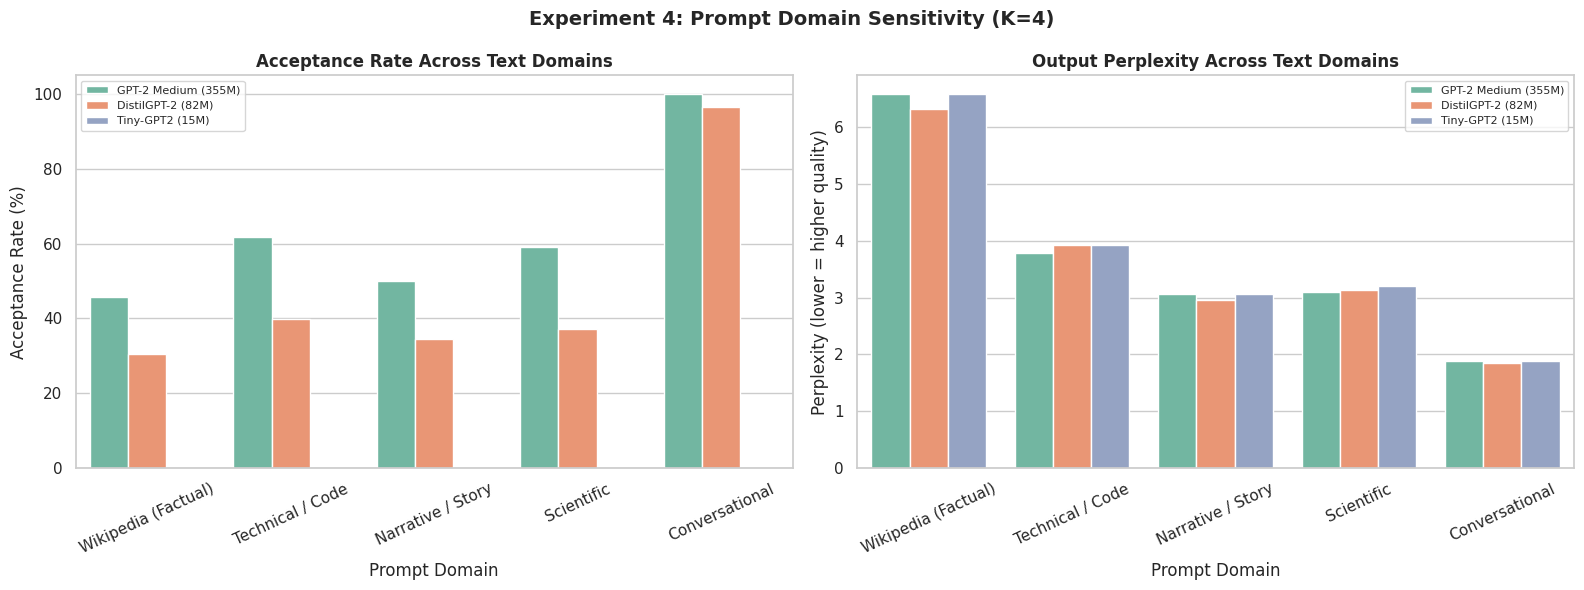

Saved: exp4_domain_sensitivity.png


In [14]:
# ============================================================
# CELL 13: VISUALIZATION — Domain Sensitivity  [NEW]
#   Plot 9:  Acceptance Rate per domain × model (grouped bar)
#   Plot 10: Perplexity per domain × model (grouped bar)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Experiment 4: Prompt Domain Sensitivity (K=4)",
             fontsize=14, fontweight="bold")

# --- Plot 9 (NEW): Acceptance Rate by Domain ---
sns.barplot(data=df_domain, x="Domain", y="Acceptance Rate (%)",
            hue="Model", ax=axes[0], palette="Set2")
axes[0].set_title("Acceptance Rate Across Text Domains", fontweight="bold")
axes[0].set_xlabel("Prompt Domain")
axes[0].set_ylabel("Acceptance Rate (%)")
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=8)

# --- Plot 10 (NEW): Perplexity by Domain ---
sns.barplot(data=df_domain, x="Domain", y="Perplexity",
            hue="Model", ax=axes[1], palette="Set2")
axes[1].set_title("Output Perplexity Across Text Domains", fontweight="bold")
axes[1].set_xlabel("Prompt Domain")
axes[1].set_ylabel("Perplexity (lower = higher quality)")
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("exp4_domain_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: exp4_domain_sensitivity.png")

In [15]:
# ============================================================
# CELL 14: EXPERIMENT 5 — Temperature Sensitivity  [NEW — AI FOCUS]
#
# At temperature=0 (greedy), the target distribution is deterministic.
# Higher temperature makes distributions flatter → draft tokens
# that were previously rejected may now be accepted.
# This connects to the theoretical acceptance probability:
#   min(1, p(x) / q(x))  — the ratio changes as T varies.
# ============================================================
print("=" * 70)
print("EXPERIMENT 5: Temperature Sensitivity")
print("=" * 70)

TEMPERATURES = [0.0, 0.3, 0.7, 1.0, 1.3]
# Use two representative draft models and K=4
TEMP_MODELS = {
    "GPT-2 Medium (355M)": approximation_models["GPT-2 Medium (355M)"],
    "DistilGPT-2 (82M)":   approximation_models["DistilGPT-2 (82M)"]
}
TEMP_K = 4

temp_results = []
for temp_val in TEMPERATURES:
    for model_name, model in TEMP_MODELS.items():
        print(f"  T={temp_val}, {model_name}")
        res = evaluate_speculative(
            default_prompt, target_model, model, model_name,
            tokenizer, k_gamma=TEMP_K, max_length=MAX_SEQ_LEN, temp=temp_val
        )
        res["Temperature"] = temp_val
        temp_results.append(res)

df_temp = pd.DataFrame(temp_results)
print("\n--- Temperature Sensitivity Results ---")
print(df_temp[["Temperature", "Model", "Acceptance Rate (%)", "Tokens/Sec", "Perplexity"]].to_string(index=False))

EXPERIMENT 5: Temperature Sensitivity
  T=0.0, GPT-2 Medium (355M)
  T=0.0, DistilGPT-2 (82M)
  T=0.3, GPT-2 Medium (355M)
  T=0.3, DistilGPT-2 (82M)
  T=0.7, GPT-2 Medium (355M)
  T=0.7, DistilGPT-2 (82M)
  T=1.0, GPT-2 Medium (355M)
  T=1.0, DistilGPT-2 (82M)
  T=1.3, GPT-2 Medium (355M)
  T=1.3, DistilGPT-2 (82M)

--- Temperature Sensitivity Results ---
 Temperature               Model  Acceptance Rate (%)  Tokens/Sec  Perplexity
         0.0 GPT-2 Medium (355M)                 45.7       24.35        6.58
         0.0   DistilGPT-2 (82M)                 30.6       37.53        6.32
         0.3 GPT-2 Medium (355M)                 58.8       28.01        6.92
         0.3   DistilGPT-2 (82M)                 44.8       49.24        6.42
         0.7 GPT-2 Medium (355M)                 41.3       18.81       14.98
         0.7   DistilGPT-2 (82M)                 29.2       36.49       15.06
         1.0 GPT-2 Medium (355M)                 52.4       27.53       26.96
         1.0   Di

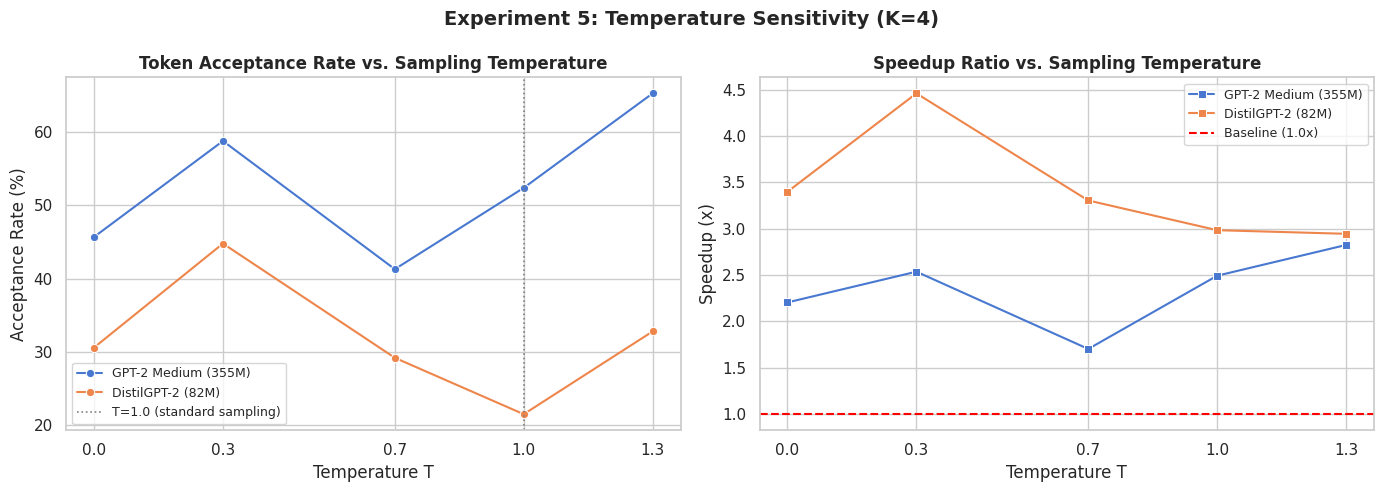

Saved: exp5_temperature_sensitivity.png


In [16]:
# ============================================================
# CELL 15: VISUALIZATION — Temperature Sensitivity  [NEW]
#   Plot 11: Acceptance Rate vs Temperature
#   Plot 12: Speedup vs Temperature
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Experiment 5: Temperature Sensitivity (K=4)",
             fontsize=14, fontweight="bold")

# --- Plot 11 (NEW): Acceptance Rate vs Temperature ---
sns.lineplot(data=df_temp, x="Temperature", y="Acceptance Rate (%)",
             hue="Model", marker="o", ax=axes[0])
axes[0].set_title("Token Acceptance Rate vs. Sampling Temperature", fontweight="bold")
axes[0].set_xlabel("Temperature T")
axes[0].set_ylabel("Acceptance Rate (%)")
axes[0].set_xticks(TEMPERATURES)
axes[0].axvline(1.0, ls=":", color="gray", linewidth=1.2, label="T=1.0 (standard sampling)")
axes[0].legend(fontsize=9)

# --- Plot 12 (NEW): Speedup vs Temperature ---
temp_baseline_tps = df[df["Model"] == "Baseline"]["Tokens/Sec"].iloc[0]
df_temp["Speedup"] = df_temp["Tokens/Sec"] / temp_baseline_tps
sns.lineplot(data=df_temp, x="Temperature", y="Speedup",
             hue="Model", marker="s", ax=axes[1])
axes[1].axhline(1.0, ls="--", color="red", linewidth=1.5, label="Baseline (1.0x)")
axes[1].set_title("Speedup Ratio vs. Sampling Temperature", fontweight="bold")
axes[1].set_xlabel("Temperature T")
axes[1].set_ylabel("Speedup (x)")
axes[1].set_xticks(TEMPERATURES)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("exp5_temperature_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: exp5_temperature_sensitivity.png")

SUMMARY: Best Configuration per Draft Model
        Draft Model  Best K  Best Speedup (x) Acc. Rate @ Best K  Perplexity @ Best K  Avg KL Div (K=4)
  DistilGPT-2 (82M)       2             4.005              54.7%                 6.51            8.7917
  GPT-2 Base (117M)       2             3.348              58.1%                 6.51            6.9078
GPT-2 Medium (355M)       1             2.637              71.1%                 6.58            5.7168
     GPT-Neo (125M)       3             2.634              44.0%                 6.58            7.3534
    Tiny-GPT2 (15M)       1             2.312               0.0%                 6.58           20.7233


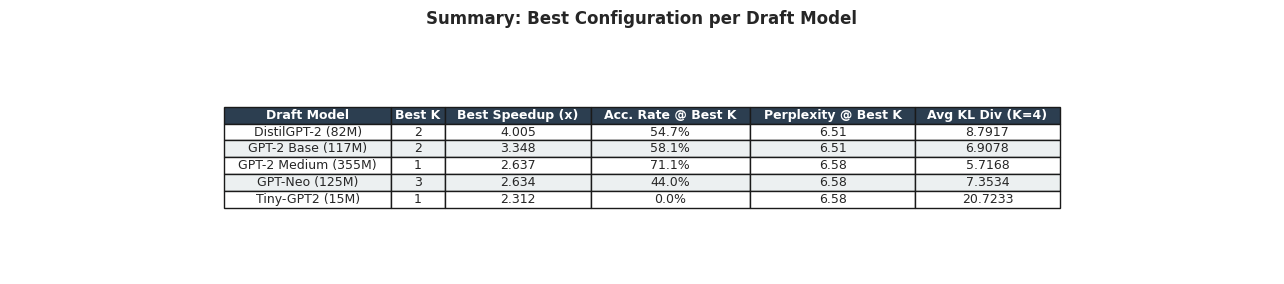

Saved: summary_table.png  |  summary_best_configs.csv


In [17]:
# ============================================================
# CELL 16: SUMMARY TABLE  [NEW]
# A consolidated summary across all experiments, suitable for
# direct inclusion in a project report.
# ============================================================
print("=" * 70)
print("SUMMARY: Best Configuration per Draft Model")
print("=" * 70)

# For each draft model, find the K that maximizes Speedup
summary_rows = []
for model_name in approximation_models.keys():
    model_df = df_spec[df_spec["Model"] == model_name]
    best_row  = model_df.loc[model_df["Speedup"].idxmax()]
    kl_row    = df_kl[df_kl["Model"] == model_name]
    avg_kl    = kl_row["Avg KL Divergence"].values[0] if len(kl_row) > 0 else float("nan")
    summary_rows.append({
        "Draft Model":         model_name,
        "Best K":              int(best_row["K"]),
        "Best Speedup (x)":    round(best_row["Speedup"], 3),
        "Acc. Rate @ Best K": f"{best_row['Acceptance Rate (%)']:.1f}%",
        "Perplexity @ Best K": round(best_row["Perplexity"], 2),
        "Avg KL Div (K=4)":    round(avg_kl, 4)
    })

df_summary = pd.DataFrame(summary_rows).sort_values("Best Speedup (x)", ascending=False)
print(df_summary.to_string(index=False))

# Save as CSV for the report
df_summary.to_csv("summary_best_configs.csv", index=False)

# Visual summary table as a Matplotlib figure
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")
tbl = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(df_summary.columns))))
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#ecf0f1")

plt.title("Summary: Best Configuration per Draft Model",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: summary_table.png  |  summary_best_configs.csv")